<a href="https://colab.research.google.com/github/mahamtaqi3-cloud/Grassland-Management-and-Arthropod-Biodiversity-An-Ecological-Data-Analysis-Using-Python/blob/main/Grassland_Management_and_Arthropod_Biodiversity_An_Ecological_Data_Analysis_Using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Plot style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [13]:
df = pd.read_excel("04_SEMData_2009.xlsx")

In [14]:
# First five rows
df.head()

,PlotID,Region,Fertilization,Grazing,Mowing,Time_after_mowing,Plant_SpeciesRichness,Plant_biomass,Herbivore_SpeciesRichness,Predator_SpeciesRichness,Herbivore_biomass,Predator_biomass
0,AEG01,Schwäbische Alb,110.0,0.000000,5.0,58.0,26,305.0,27,3,9704.770468,224.090641
1,AEG02,Schwäbische Alb,740.0,0.000000,8.5,39.0,17,303.5,29,7,10186.216560,620.980335
2,AEG03,Schwäbische Alb,192.0,0.000000,7.5,21.5,28,138.0,31,5,7428.089807,230.624917
3,AEG04,Schwäbische Alb,105.0,53.302961,3.0,49.0,20,650.0,25,9,10133.896600,630.347397
4,AEG05,Schwäbische Alb,145.0,61.764706,3.0,69.0,20,259.5,21,8,11832.158720,121.193245


In [15]:
# Dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 141
Columns: 12


In [16]:
# Dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 141
Columns: 12


In [17]:
# Column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlotID                     141 non-null    object 
 1   Region                     141 non-null    object 
 2   Fertilization              141 non-null    float64
 3   Grazing                    141 non-null    float64
 4   Mowing                     141 non-null    float64
 5   Time_after_mowing          141 non-null    float64
 6   Plant_SpeciesRichness      141 non-null    int64  
 7   Plant_biomass              141 non-null    float64
 8   Herbivore_SpeciesRichness  141 non-null    int64  
 9   Predator_SpeciesRichness   141 non-null    int64  
 10  Herbivore_biomass          141 non-null    float64
 11  Predator_biomass           141 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 13.3+ KB


In [18]:
# Summary statistics
df.describe()

,Fertilization,Grazing,Mowing,Time_after_mowing,Plant_SpeciesRichness,Plant_biomass,Herbivore_SpeciesRichness,Predator_SpeciesRichness,Herbivore_biomass,Predator_biomass
count,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000
mean,88.224113,64.404014,2.553191,81.037854,28.631206,300.797163,20.595745,3.624113,4710.907768,274.024325
std,172.383828,102.192677,2.246984,34.901589,11.582259,128.850822,7.550760,2.156515,4682.642257,388.042135
min,0.000000,0.000000,0.000000,10.500000,12.000000,56.500000,6.000000,0.000000,53.566931,0.000000
25%,0.000000,0.152174,0.000000,53.000000,20.000000,199.600000,15.000000,2.000000,1460.763411,56.207506
50%,0.000000,25.806452,2.500000,70.500000,26.000000,305.400000,20.000000,3.000000,3290.051150,148.570906
75%,145.000000,65.896336,4.000000,112.500000,33.000000,389.100000,25.000000,5.000000,6544.775718,391.113990
max,1611.400000,572.098976,8.500000,145.523622,71.000000,699.300000,44.000000,9.000000,31607.424430,3391.744472


In [19]:
missing = df.isnull().sum()

missing

,0
PlotID,0
Region,0
Fertilization,0
Grazing,0
Mowing,0
Time_after_mowing,0
Plant_SpeciesRichness,0
Plant_biomass,0
Herbivore_SpeciesRichness,0
Predator_SpeciesRichness,0


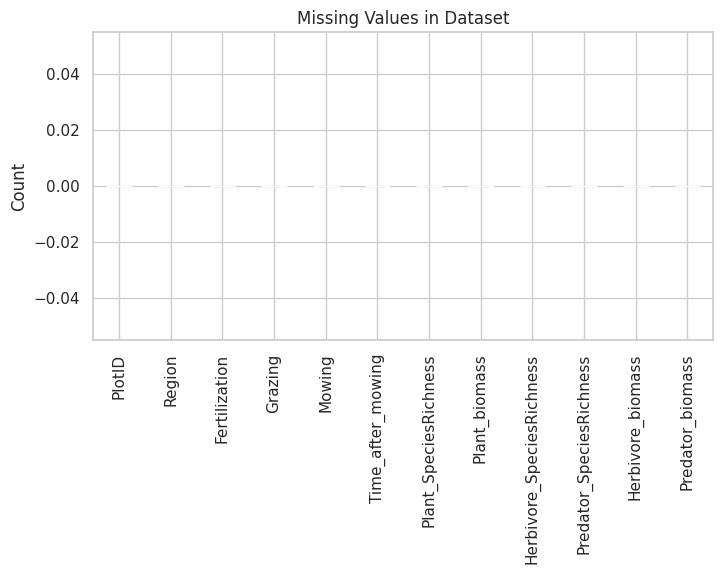

In [20]:
plt.figure(figsize=(8,4))

missing.plot(kind="bar")

plt.title("Missing Values in Dataset")

plt.ylabel("Count")

plt.show()

| Variable                  | Description                 |
| ------------------------- | --------------------------- |
| Fertilization             | Fertilizer treatment        |
| Grazing                   | Grazing intensity           |
| Mowing                    | Mowing frequency            |
| Plant_SpeciesRichness     | Number of plant species     |
| Herbivore_SpeciesRichness | Number of herbivore species |
| Predator_SpeciesRichness  | Number of predator species  |
| Plant_biomass             | Plant biomass               |
| Herbivore_biomass         | Herbivore biomass           |
| Predator_biomass          | Predator biomass            |


In [21]:
df.dtypes

,0
PlotID,object
Region,object
Fertilization,float64
Grazing,float64
Mowing,float64
Time_after_mowing,float64
Plant_SpeciesRichness,int64
Plant_biomass,float64
Herbivore_SpeciesRichness,int64
Predator_SpeciesRichness,int64


In [22]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [23]:
df["Region"].value_counts()

,count
Region,
Hainich-Dün,48
Schwäbische Alb,47
Schorfheide-Chorin,46


In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Fertilization,141.0,88.224113,172.383828,0.000000,0.000000,0.000000,145.000000,1611.400000
Grazing,141.0,64.404014,102.192677,0.000000,0.152174,25.806452,65.896336,572.098976
Mowing,141.0,2.553191,2.246984,0.000000,0.000000,2.500000,4.000000,8.500000
Time_after_mowing,141.0,81.037854,34.901589,10.500000,53.000000,70.500000,112.500000,145.523622
Plant_SpeciesRichness,141.0,28.631206,11.582259,12.000000,20.000000,26.000000,33.000000,71.000000
Plant_biomass,141.0,300.797163,128.850822,56.500000,199.600000,305.400000,389.100000,699.300000
Herbivore_SpeciesRichness,141.0,20.595745,7.550760,6.000000,15.000000,20.000000,25.000000,44.000000
Predator_SpeciesRichness,141.0,3.624113,2.156515,0.000000,2.000000,3.000000,5.000000,9.000000
Herbivore_biomass,141.0,4710.907768,4682.642257,53.566931,1460.763411,3290.051150,6544.775718,31607.424430
Predator_biomass,141.0,274.024325,388.042135,0.000000,56.207506,148.570906,391.113990,3391.744472


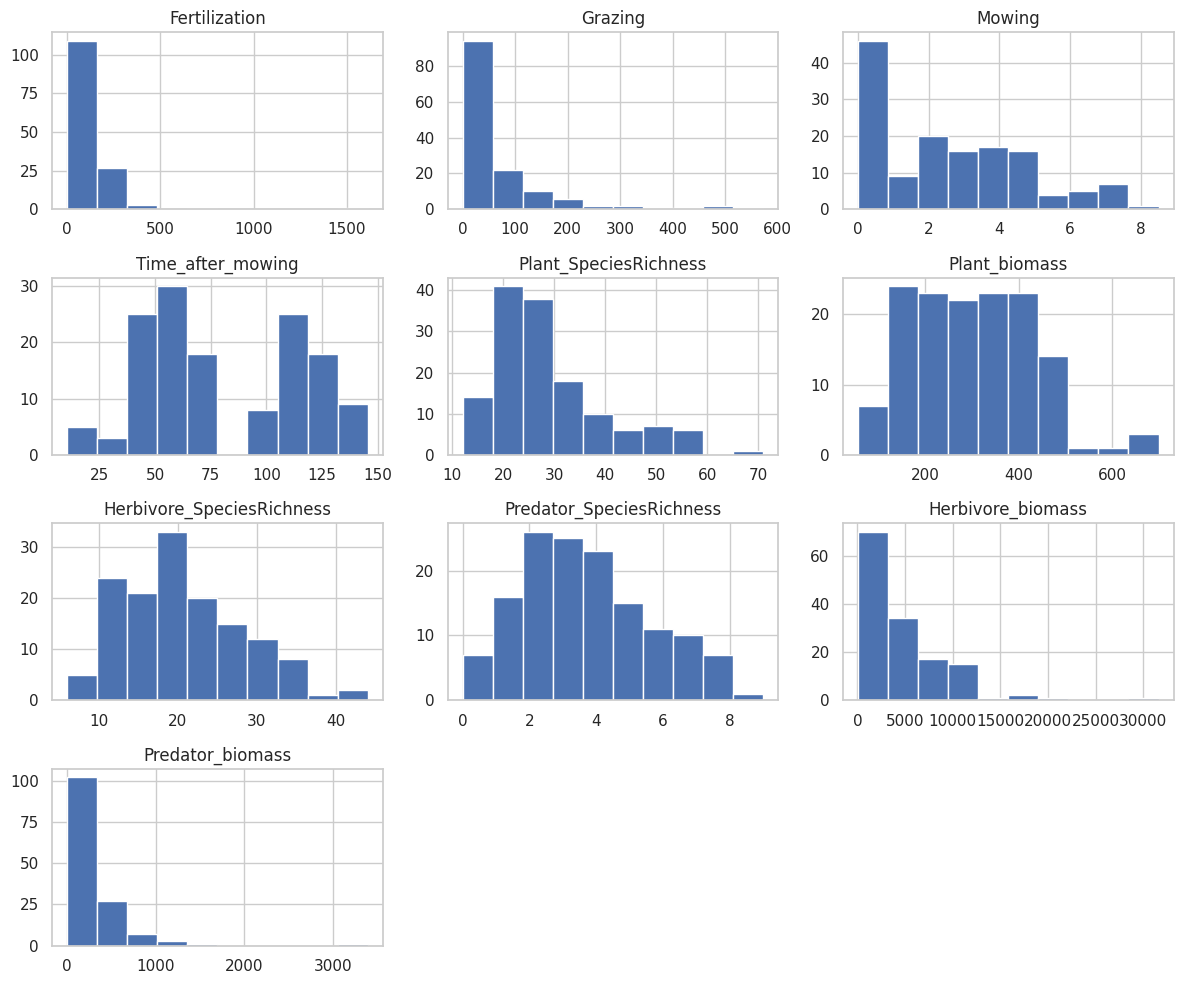

In [25]:
df.hist(figsize=(12,10))

plt.tight_layout()

plt.show()

In [26]:
df["Fertilization"].unique()

array([ 110. ,  740. ,  192. ,  105. ,  145. ,    0. ,  103. ,  104. ,
        289. ,  384. ,   12. ,  240. ,  100. ,  132. ,    6. ,   24. ,
         35. ,   34. ,   74.8,  115.6,  278. ,  182.4,   36. ,  309.4,
       1611.4,  362. ,  308. ,  174. ,  160. ,   64. ,   60. ,  198. ,
        120. ,   62. ,  228. ,  233. ,  167. ,  185. ,  162. ,  208. ,
        134. ,  220. ,  190. ,  163. ,  340. ,  250. ,  165. ,  115. ,
        280. ,  225. ,  130. ,   16. ,   52. ,  102. ])

In [28]:
print(df["Grazing"].describe())

count    141.000000
mean      64.404014
std      102.192677
min        0.000000
25%        0.152174
50%       25.806452
75%       65.896336
max      572.098976
Name: Grazing, dtype: float64


In [29]:
print(df["Mowing"].describe())

count    141.000000
mean       2.553191
std        2.246984
min        0.000000
25%        0.000000
50%        2.500000
75%        4.000000
max        8.500000
Name: Mowing, dtype: float64


In [30]:
print(df["Time_after_mowing"].describe())

count    141.000000
mean      81.037854
std       34.901589
min       10.500000
25%       53.000000
50%       70.500000
75%      112.500000
max      145.523622
Name: Time_after_mowing, dtype: float64


## Research Question 1

### Does fertilizer intensity influence herbivore species richness?

Fertilizer application can alter plant communities and resource availability, potentially affecting herbivore diversity. This analysis investigates whether higher fertilizer inputs are associated with changes in herbivore species richness.

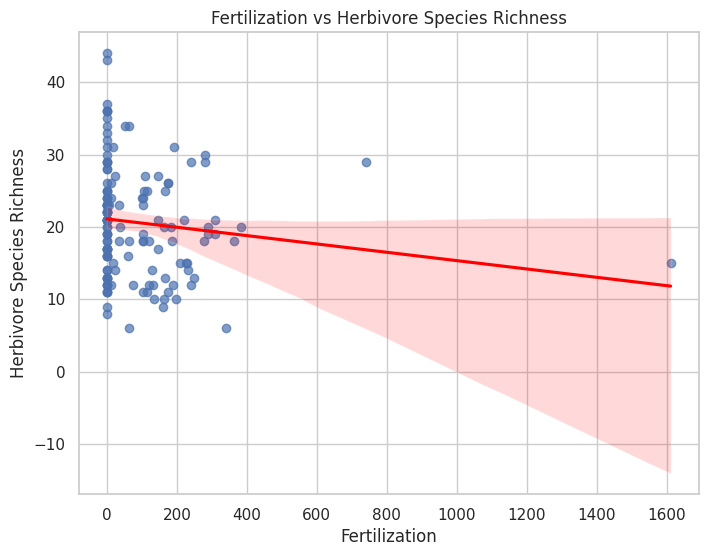

In [31]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Fertilization",
    y="Herbivore_SpeciesRichness",
    scatter_kws={"alpha":0.7},
    line_kws={"color":"red"}
)

plt.title("Fertilization vs Herbivore Species Richness")
plt.xlabel("Fertilization")
plt.ylabel("Herbivore Species Richness")

plt.show()

### Interpretation

The scatter plot suggests a weak negative relationship between fertilizer application and herbivore species richness. Plots receiving higher fertilizer inputs tend to have slightly fewer herbivore species, although the relationship is highly variable. This indicates that fertilization alone may not be the primary driver of herbivore diversity.

In [32]:
# Correlation between fertilization and herbivore richness
correlation = df["Fertilization"].corr(df["Herbivore_SpeciesRichness"])

print(f"Pearson correlation: {correlation:.3f}")

Pearson correlation: -0.132


## Research Question 2

### Does grazing intensity affect herbivore species richness?

Grazing alters vegetation structure and food availability, which may influence herbivore communities. This analysis explores the relationship between grazing intensity and herbivore species richness.

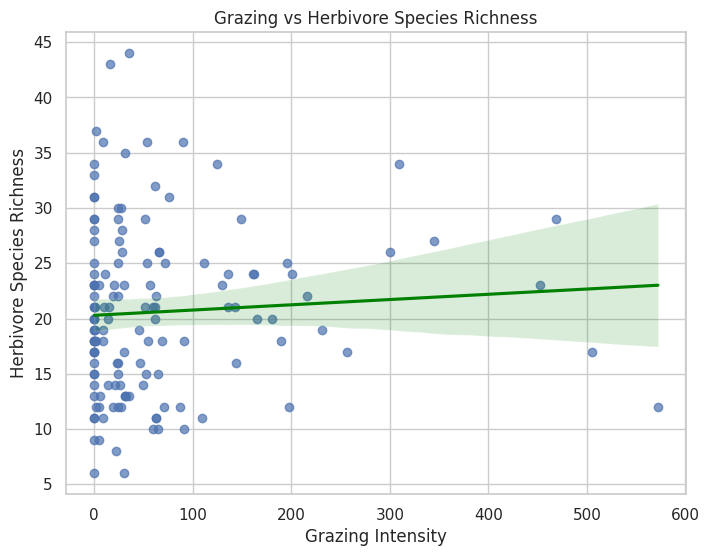

In [33]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Grazing",
    y="Herbivore_SpeciesRichness",
    scatter_kws={"alpha":0.7},
    line_kws={"color":"green"}
)

plt.title("Grazing vs Herbivore Species Richness")
plt.xlabel("Grazing Intensity")
plt.ylabel("Herbivore Species Richness")

plt.show()

In [34]:
correlation = df["Grazing"].corr(df["Herbivore_SpeciesRichness"])

print(f"Pearson correlation: {correlation:.3f}")

Pearson correlation: 0.064


### Interpretation

The relationship between grazing intensity and herbivore species richness is very weak (Pearson correlation = 0.064). The nearly flat regression line and scattered observations suggest that grazing intensity alone does not strongly influence herbivore species richness in these grassland plots.

## Research Question 3

### Does mowing intensity influence herbivore species richness?

Mowing alters vegetation structure and habitat availability, which may affect herbivore communities. This analysis investigates whether mowing intensity is associated with changes in herbivore species richness.

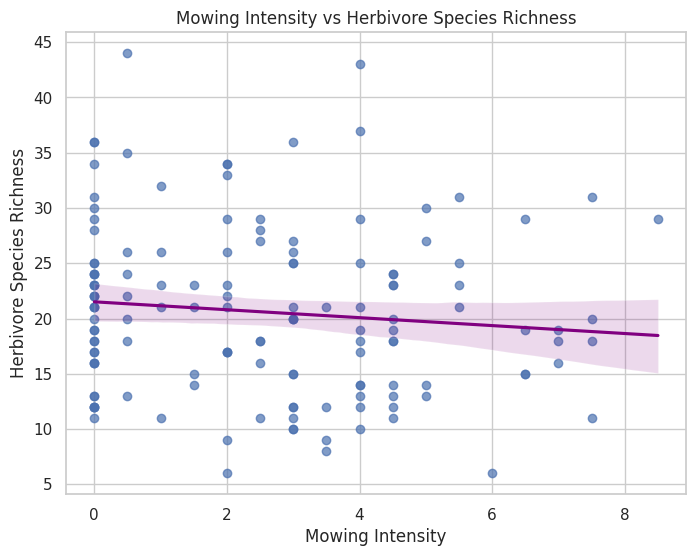

In [35]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Mowing",
    y="Herbivore_SpeciesRichness",
    scatter_kws={"alpha":0.7},
    line_kws={"color":"purple"}
)

plt.title("Mowing Intensity vs Herbivore Species Richness")
plt.xlabel("Mowing Intensity")
plt.ylabel("Herbivore Species Richness")

plt.show()

In [36]:
correlation = df["Mowing"].corr(df["Herbivore_SpeciesRichness"])

print(f"Pearson correlation: {correlation:.3f}")

Pearson correlation: -0.107


### Interpretation

The analysis indicates a weak negative relationship between mowing intensity and herbivore species richness (Pearson correlation = -0.107). Although the regression line suggests that herbivore diversity tends to decline slightly with increasing mowing intensity, the large variation among plots indicates that mowing intensity alone is not a strong predictor of herbivore species richness.

## Research Question 4

### Does plant species richness influence herbivore species richness?

Plant diversity is expected to support a greater diversity of herbivorous insects by providing a wider variety of food resources and ecological niches. This analysis investigates the relationship between plant species richness and herbivore species richness.

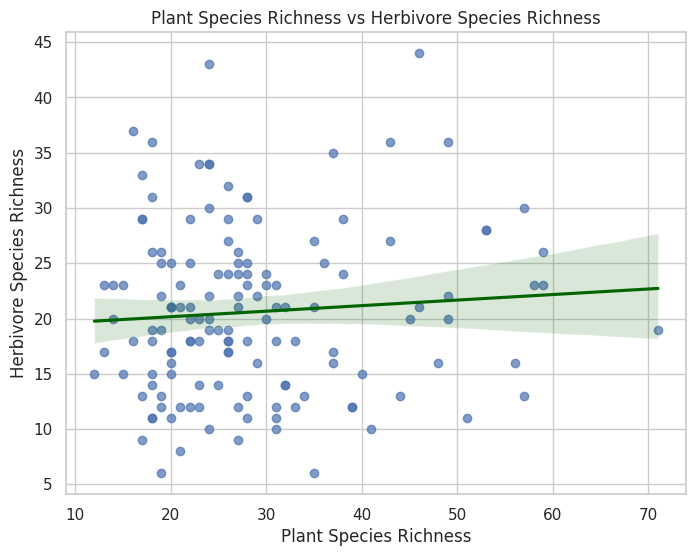

In [37]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Plant_SpeciesRichness",
    y="Herbivore_SpeciesRichness",
    scatter_kws={"alpha":0.7},
    line_kws={"color":"darkgreen"}
)

plt.title("Plant Species Richness vs Herbivore Species Richness")
plt.xlabel("Plant Species Richness")
plt.ylabel("Herbivore Species Richness")

plt.show()

In [38]:
correlation = df["Plant_SpeciesRichness"].corr(df["Herbivore_SpeciesRichness"])

print(f"Pearson correlation: {correlation:.3f}")

Pearson correlation: 0.077


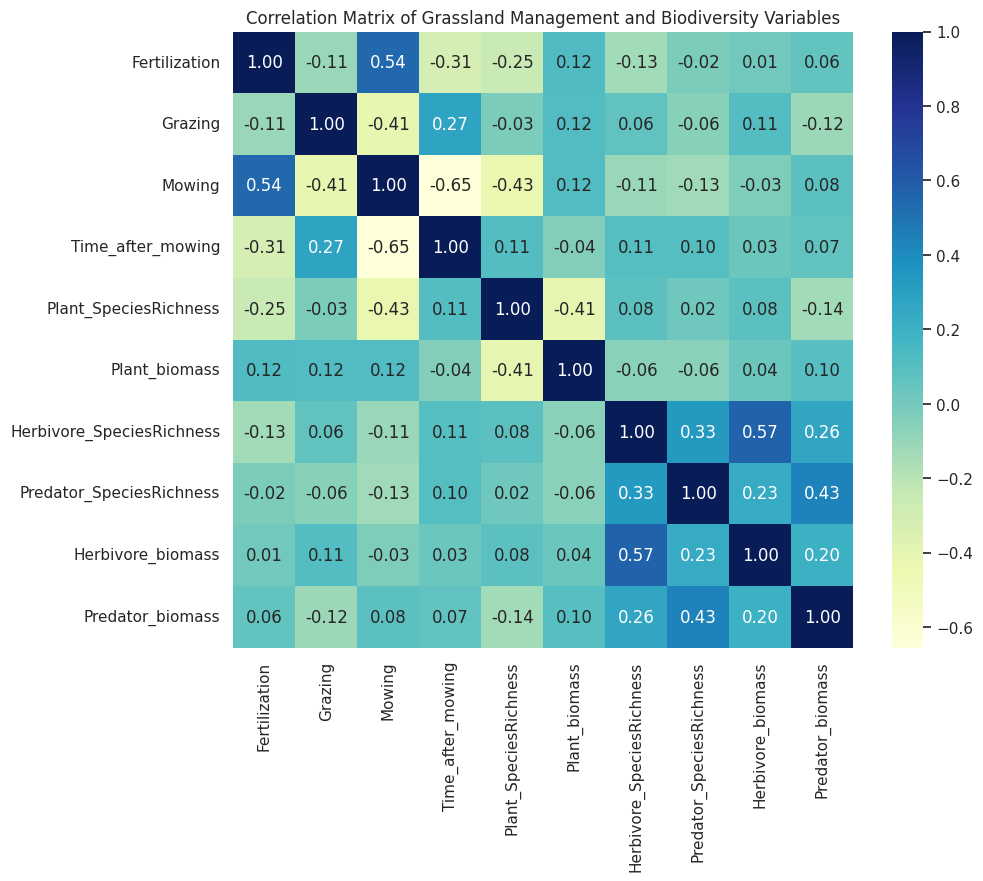

In [39]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Correlation Matrix of Grassland Management and Biodiversity Variables")

plt.show()

# Machine Learning

## Predicting Herbivore Species Richness

To complement the exploratory analysis, a Random Forest Regressor was developed to predict herbivore species richness based on grassland management practices and vegetation characteristics.

The objective is to identify which environmental variables contribute most to predicting herbivore diversity.

In [40]:
# Features
X = df[[
    "Fertilization",
    "Grazing",
    "Mowing",
    "Time_after_mowing",
    "Plant_SpeciesRichness",
    "Plant_biomass"
]]

# Target variable
y = df["Herbivore_SpeciesRichness"]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [43]:
y_pred = rf.predict(X_test)

In [44]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.2f}")

MAE : 6.37
RMSE: 7.63
R²  : -0.09


In [45]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,Plant_biomass,0.244881
3,Time_after_mowing,0.216217
4,Plant_SpeciesRichness,0.178397
1,Grazing,0.163792
0,Fertilization,0.113412
2,Mowing,0.083302


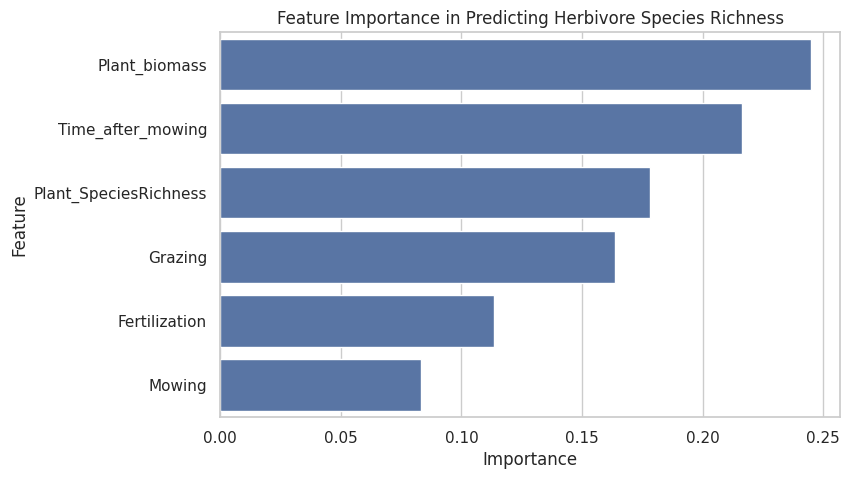

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance in Predicting Herbivore Species Richness")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

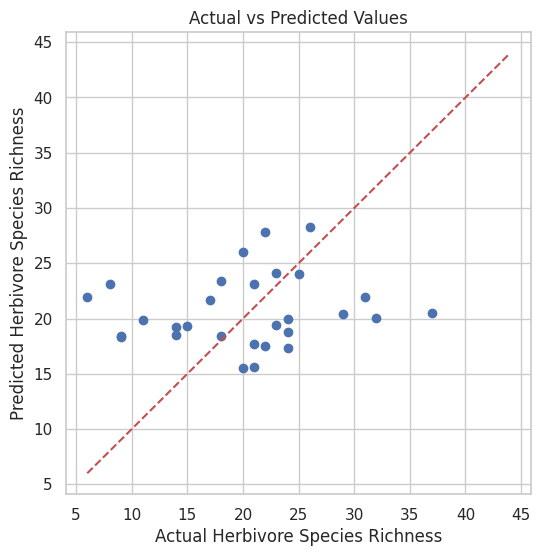

In [47]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    "r--"
)

plt.xlabel("Actual Herbivore Species Richness")
plt.ylabel("Predicted Herbivore Species Richness")
plt.title("Actual vs Predicted Values")

plt.show()

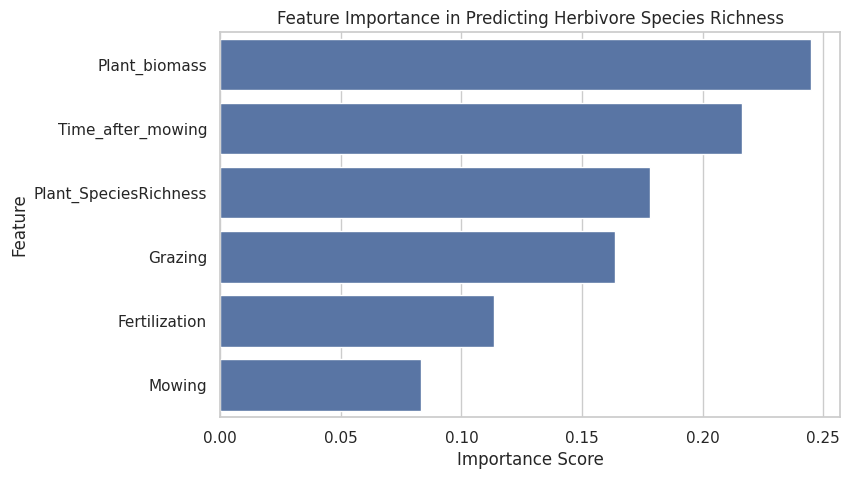

,Feature,Importance
5,Plant_biomass,0.244881
3,Time_after_mowing,0.216217
4,Plant_SpeciesRichness,0.178397
1,Grazing,0.163792
0,Fertilization,0.113412
2,Mowing,0.083302


In [48]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance in Predicting Herbivore Species Richness")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

importance

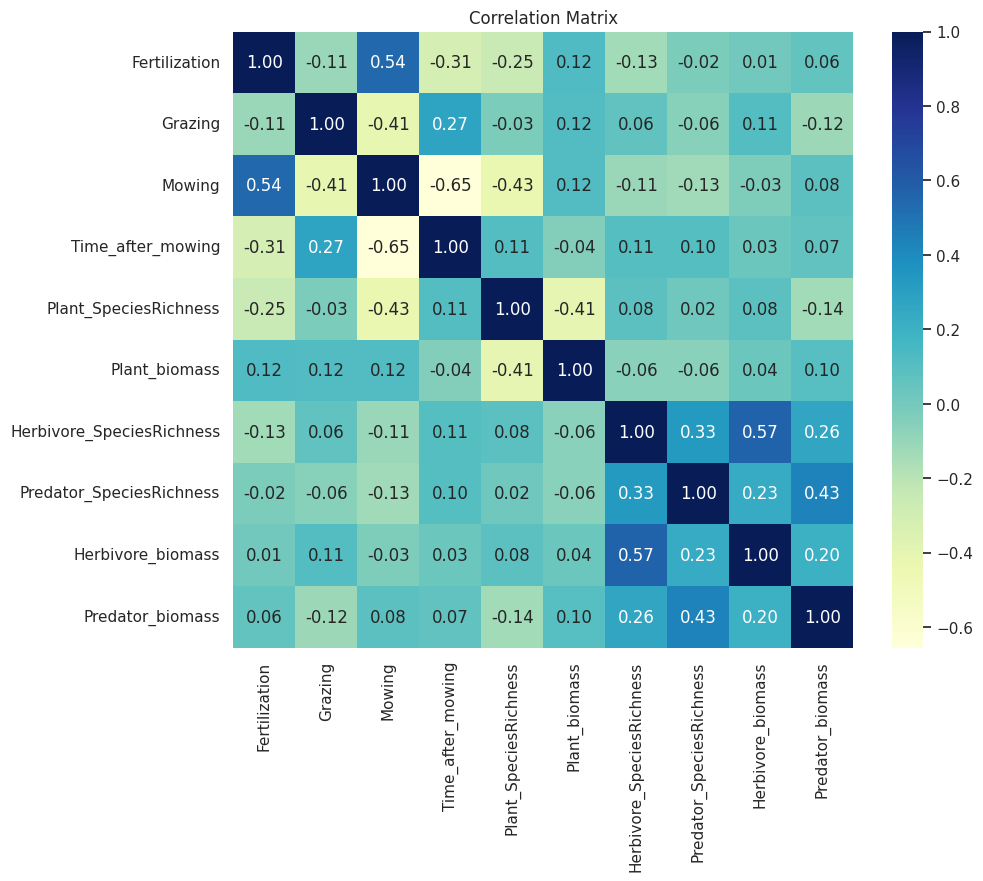

In [49]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# Conclusion

This project investigated how grassland management practices influence herbivore biodiversity using real ecological data.

## Key Findings

- Fertilization showed a weak negative relationship with herbivore species richness.
- Grazing intensity exhibited almost no linear relationship with herbivore richness.
- Mowing intensity demonstrated a weak negative association with herbivore richness.
- Plant species richness appeared to have a stronger ecological relationship with herbivore diversity than management practices alone.
- The Random Forest model showed limited predictive performance (R² = -0.09), suggesting that additional environmental variables are needed to accurately predict herbivore species richness.

Overall, this study highlights the complexity of ecological systems and demonstrates how Python can be used to explore biodiversity patterns through data analysis and machine learning.